# PINN Showcase for Multi-Angle Droplet Formation (Fig 1)

## Introduction:
This notebook goes over the training process for obtaining a multi-angle droplet as shown in Fig 1 of our paper. 

## Import Packages
The packages below are used to compile the notebook.

In [ ]:
## Import necessary packages.
import os
import sys

sys.path.append(os.path.abspath(os.path.join('..')))

from PINN_Drop.pinn_model import PINNDrop
import PINN_Drop.utils as utils
from PINN_Drop.train import train_pinn
import PINN_Drop.visualization as viz

import numpy as np
import matplotlib.pyplot as plt

base_dir = os.path.abspath(os.path.join('.', '..'))

## Model Initialization:
We will be generating a droplet with Bond number zero with different contact angles. The contact angle positions will look something like below.

<p align="center">
    <img src="../figures/multi_angle_diagram.png" width="400" />
</p>

Here, the surface is separated into three contact angles: 60 degrees, 30 degrees, and 60 degrees. The surface positions are located at $x = -0.25$ and $x = 0.25$. Finally, the loss weights are set to [PDE: 100, Volume: 100, Angle: 100, Motion: 0, Center: 100, y-center: 0].

In [ ]:
## Initialize the physics-based parameters
args = utils.get_pinn_args(Bo = 0, surface_angles = [60, 30, 60], surface_pos = [-0.25, 0.25], 
                           width = [0.01, 0.01], weight_list = [100, 100, 100, 0, 100, 0])

In [ ]:
## Initialize the model using the defined arguments. Load in warm-up weights.
pinn = PINNDrop(args)
pinn.warmup_model(os.path.join(base_dir, 'saved_models', 'warmup_weights.keras'))

## Training and Results:
Training is the same as the traditional method displayed in the Python notebook ``pinn_demo_1.ipynb``.

In [ ]:
## Train the multi-angle droplet.
train_pinn(pinn, Bo_steps = 0, per_Bo_step = 0, final_Bo_step = 15000)

Training Epoch: 14999 / 15000 |  Bond Number: 0.000  |  PDE Loss: 0.006


We can now visualize the results.

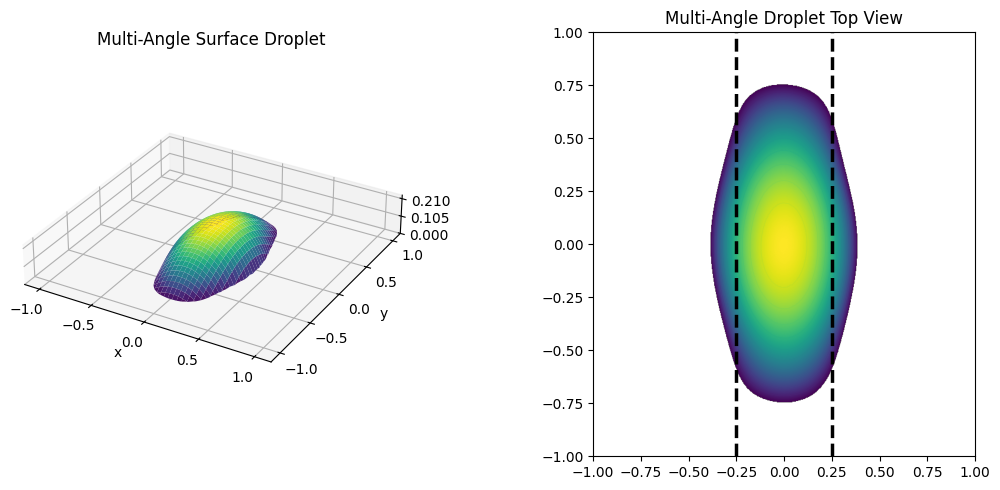

In [ ]:
## Use 640 grid points for visualization.
num_grids = 640
z_pred = pinn.predict(utils.get_coords(pinn.space_width, num_grids), batch_size = num_grids ** 2, verbose = 0)

## Visualize the 3D and 2D top view of the multi-angle droplet.
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (10, 5))

## Plot the 3D droplet.
ax[0].remove()
ax[0] = fig.add_subplot(1, 2, 1, projection = '3d')
viz.plot_droplet(ax[0], z_pred, pinn.space_width, num_grids, 
                 "Multi-Angle Surface Droplet", "x", "y")

## Obtain xyz grid values for top view plotting.
x = np.linspace(-1, 1, 640)
y = np.linspace(-1, 1, 640)
X, Y, Z = utils.get_xyz_coords(z_pred, pinn.space_width, 640)

ax[1].imshow(Z, extent = [x.min(), x.max(), y.min(), y.max()], origin = 'lower', aspect = 'auto')
ax[1].contour(X, Y, Z, levels = 12, linewidths = 0.5)
ax[1].axvline(0.25, color = 'black', linestyle = '--', linewidth = 2.5)
ax[1].axvline(-0.25, color = 'black', linestyle = '--', linewidth = 2.5)
ax[1].set_title("Multi-Angle Droplet Top View")

plt.tight_layout(w_pad = 10)
plt.show()

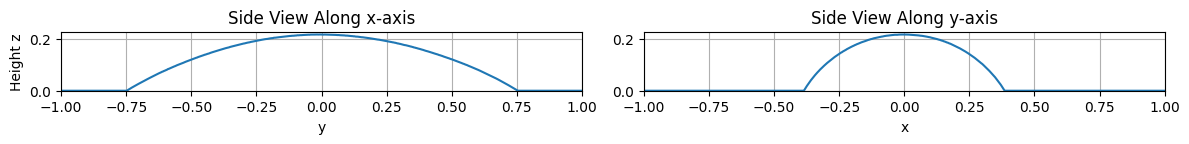

In [ ]:
## Plot the 2D slice views of the droplet to see the difference in formation
## w.r.t. the x and y axis.
viz.plot_yz_xz_views(z_pred, pinn.space_width, num_grids)